# Student Performance Analysis

## Objective

The objective of this project is to analyze student performance data and identify the factors affecting academic achievement. The analysis focuses on parental education, test preparation, gender-wise performance, score correlations, and identifying at-risk students. The project also provides recommendations to improve student outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Loading

In [2]:
students = pd.read_csv("data/StudentsPerformance.csv")

print("Dataset Loaded Successfully!\n")

print("Dataset Shape:")
print(students.shape)

print("\nColumn Names:")
print(students.columns.tolist())

print("\nFirst Five Records:")
students.head()

Dataset Loaded Successfully!

Dataset Shape:
(1000, 8)

Column Names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

First Five Records:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Data Exploration & Cleaning

In [3]:
print("=" * 60)
print("DATA EXPLORATION & CLEANING")
print("=" * 60)

print("\nDataset Information:\n")
students.info()

print("\nMissing Values:\n")
print(students.isnull().sum())

print("\nDuplicate Rows:")
print(students.duplicated().sum())

print("\nData Types:\n")
print(students.dtypes)

print("\nStatistical Summary:\n")
print(students.describe())

print("\nUnique Values in Categorical Columns:\n")

categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(students[column].unique())

DATA EXPLORATION & CLEANING

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB

Missing Values:

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0

# Dataset Summary

### Dataset Summary

- The dataset contains **1000 student records** with **8 attributes**.
- There are **no missing values** in any column.
- There are **no duplicate records**.
- The dataset includes demographic details and scores in Mathematics, Reading, and Writing.
- The data is clean and ready for analysis and visualization.

# Feature Engineering

In [4]:
# Create Total Score and Average Score

students["total score"] = (
    students["math score"] +
    students["reading score"] +
    students["writing score"]
)

students["average score"] = (
    students["total score"] / 3
)

print("Feature Engineering Completed Successfully!\n")

print(students[[
    "math score",
    "reading score",
    "writing score",
    "total score",
    "average score"
]].head())

Feature Engineering Completed Successfully!

   math score  reading score  writing score  total score  average score
0          72             72             74          218      72.666667
1          69             90             88          247      82.333333
2          90             95             93          278      92.666667
3          47             57             44          148      49.333333
4          76             78             75          229      76.333333


# Factor Analysis

## Question 1

### Does parental education level affect student scores?

In [5]:
parent_scores = students.groupby(
    "parental level of education"
)[[
    "math score",
    "reading score",
    "writing score"
]].mean()

print(parent_scores)

                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


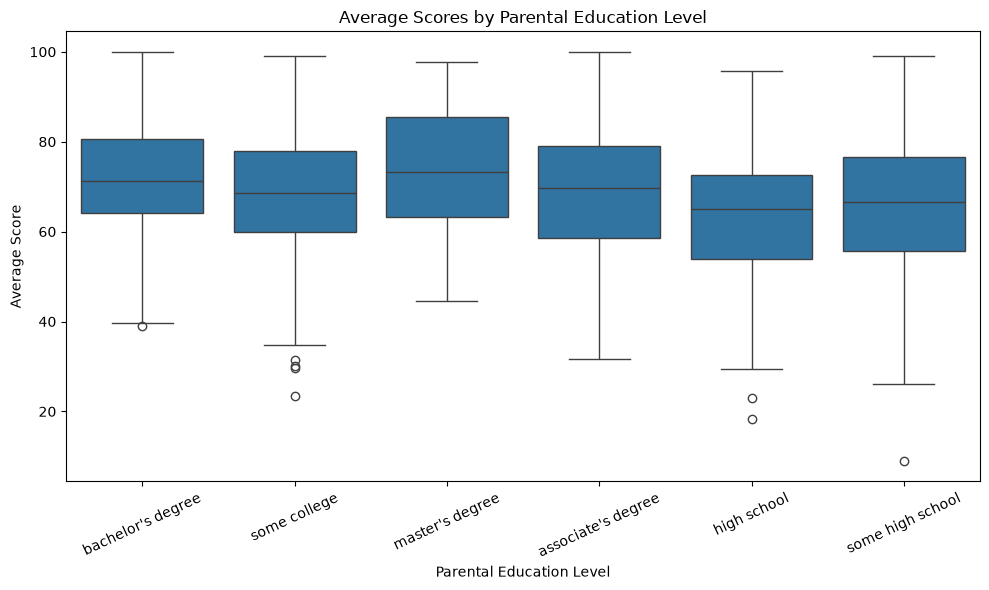

In [6]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=students,
    x="parental level of education",
    y="average score"
)

plt.title("Average Scores by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

## Question 2

### Do students who complete the test preparation course score higher?

In [7]:
testprep_scores = students.groupby(
    "test preparation course"
)[[
    "math score",
    "reading score",
    "writing score"
]].mean()

print(testprep_scores)

                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


<Figure size 800x500 with 0 Axes>

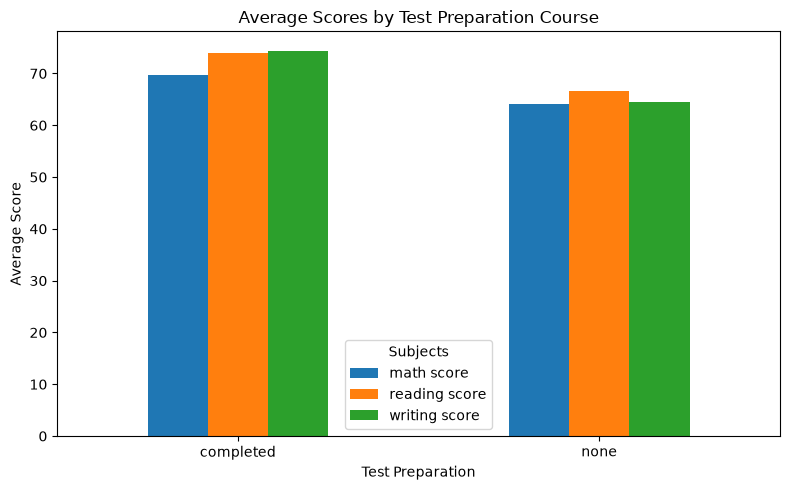

In [8]:
plt.figure(figsize=(8,5))

testprep_scores.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Scores by Test Preparation Course")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.legend(title="Subjects")

plt.tight_layout()

plt.show()

## Question 3

### What is the correlation between Mathematics, Reading, and Writing scores?

In [9]:
correlation = students[
    [
        "math score",
        "reading score",
        "writing score"
    ]
].corr()

print(correlation)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


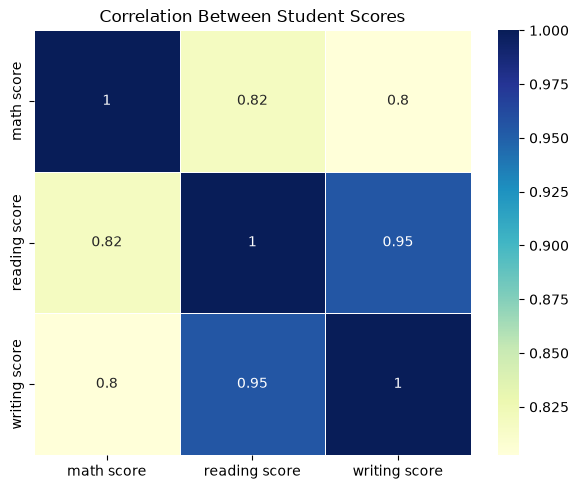

In [10]:
plt.figure(figsize=(6,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Correlation Between Student Scores")

plt.tight_layout()

plt.show()

## Question 4

### Which gender performs better in each subject?

In [11]:
gender_scores = students.groupby(
    "gender"
)[
    [
        "math score",
        "reading score",
        "writing score"
    ]
].mean()

print(gender_scores)

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


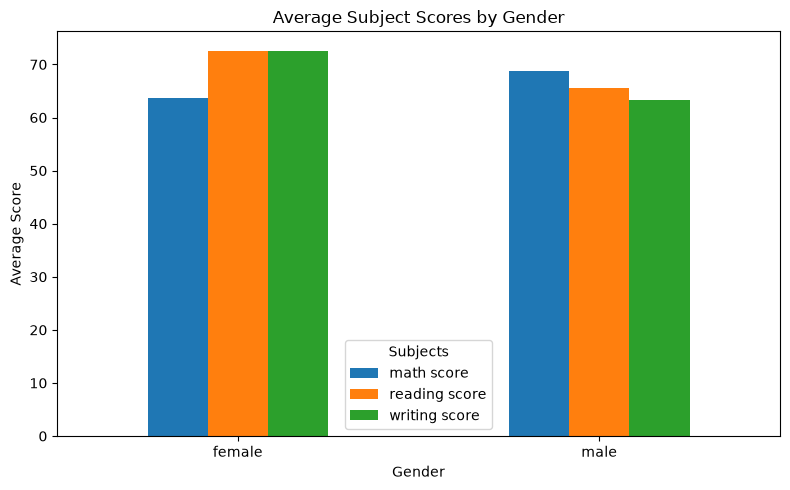

In [12]:
gender_scores.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Subject Scores by Gender")

plt.xlabel("Gender")

plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.legend(title="Subjects")

plt.tight_layout()

plt.show()

## Question 5

### What is the distribution of students' total scores?

In [13]:
print(students["total score"].describe())

count    1000.000000
mean      203.312000
std        42.771978
min        27.000000
25%       175.000000
50%       205.000000
75%       233.000000
max       300.000000
Name: total score, dtype: float64


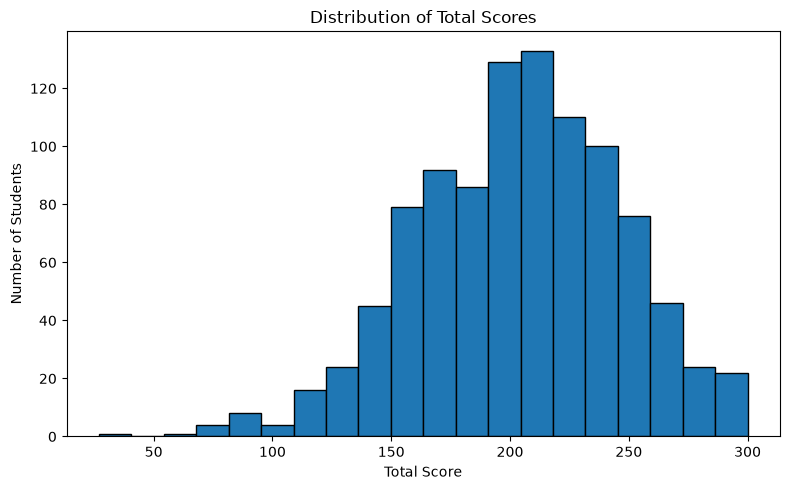

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    students["total score"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.tight_layout()

plt.show()

## Additional Visualization

### Relationship between Reading Score and Math Score

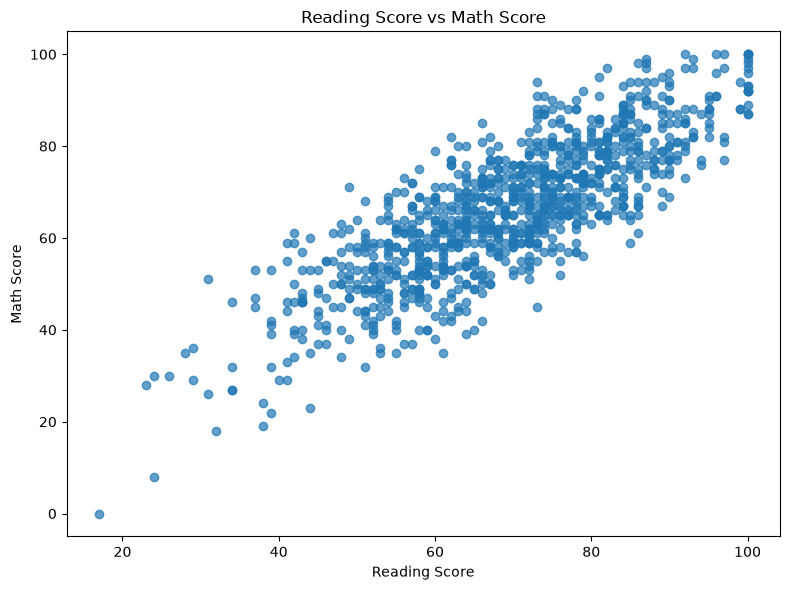

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    students["reading score"],
    students["math score"],
    alpha=0.7
)

plt.title("Reading Score vs Math Score")
plt.xlabel("Reading Score")
plt.ylabel("Math Score")

plt.tight_layout()

plt.show()

# At-Risk Student Segmentation

In [16]:
at_risk = students[
    (students["math score"] < 50) |
    (students["reading score"] < 50) |
    (students["writing score"] < 50)
]

print("Number of At-Risk Students:", len(at_risk))

print("\nPercentage of At-Risk Students:")
print(round((len(at_risk) / len(students)) * 100, 2), "%")

print("\nAt-Risk Students by Gender:")
print(at_risk["gender"].value_counts())

print("\nAt-Risk Students by Race/Ethnicity:")
print(at_risk["race/ethnicity"].value_counts())

print("\nAt-Risk Students by Parental Education:")
print(at_risk["parental level of education"].value_counts())

Number of At-Risk Students: 188

Percentage of At-Risk Students:
18.8 %

At-Risk Students by Gender:
gender
male      99
female    89
Name: count, dtype: int64

At-Risk Students by Race/Ethnicity:
race/ethnicity
group C    59
group B    43
group D    42
group A    30
group E    14
Name: count, dtype: int64

At-Risk Students by Parental Education:
parental level of education
high school           49
some high school      46
some college          38
associate's degree    33
bachelor's degree     16
master's degree        6
Name: count, dtype: int64
